In [1]:
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

In [95]:
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

# -----------------------------
# 1) Config
# -----------------------------
CSV_PATH    = Path("C:/Users/alona/OneDrive/Documents/monthly_merged4.csv")
TARGET_COL = "target"
DATE_COL   = "observation_date"
LOOKBACK   = 6
TEST_SIZE  = 0.2
BATCH_SIZE = 36
EPOCHS     = 300
LSTM_UNITS = 64
DROPOUT    = 0.2
PATIENCE   = 30

In [97]:
df = pd.read_csv(CSV_PATH)

df['target_diff'] = df['target'].diff()
df = df.dropna().reset_index(drop=True)
TARGET_COL = 'target_diff'

df[DATE_COL] = pd.to_datetime(df[DATE_COL])
df = df.sort_values(DATE_COL).reset_index(drop=True)

In [99]:
num_df = df.select_dtypes(include=[np.number]).copy()
if TARGET_COL not in num_df.columns:
    raise ValueError(f"Target '{TARGET_COL}' not found.")

feature_cols = [c for c in num_df.columns if c not in {"target", TARGET_COL}]
print("Using features:", feature_cols)

# Split BEFORE scaling
X = num_df[feature_cols]
y = num_df[TARGET_COL]

n_total = len(X)
n_test = int(TEST_SIZE * n_total)
n_train = n_total - n_test

X_train_raw, X_test_raw = X.iloc[:n_train], X.iloc[n_train:]
y_train_raw, y_test_raw = y[:n_train], y[n_train:]

Using features: ['retail', 'cpi', 'federal_funds', 'labor_force', 'median_homeprice', 'median_markettime', 'authorization_housing', 'housing_starts', 'change_sale', 'unemployment', 'sentiment', 'unsold_homeinventory', 'real_GDP', 'household_debtpayments', 'mortgage30']


In [101]:
X_scaler = MinMaxScaler()
y_scaler = MinMaxScaler()

X_train_scaled = X_scaler.fit_transform(X_train_raw)
X_test_scaled  = X_scaler.transform(X_test_raw)

y_train_scaled = y_scaler.fit_transform(np.array(y_train_raw).reshape(-1, 1))
y_test_scaled  = y_scaler.transform(np.array(y_test_raw).reshape(-1, 1))

In [103]:
def make_sequences(X, y, lookback):
    Xs, ys = [], []
    for i in range(lookback, len(X)):
        Xs.append(X[i - lookback:i])
        ys.append(y[i])
    return np.array(Xs), np.array(ys)

X_seq_train, y_seq_train = make_sequences(X_train_scaled, y_train_scaled, LOOKBACK)
X_seq_test,  y_seq_test  = make_sequences(X_test_scaled,  y_test_scaled, LOOKBACK)

n_test  = int(TEST_SIZE * n_total)
n_train = n_total - n_test

X_train, y_train = X_seq_train, y_seq_train
X_test,  y_test  = X_seq_test,  y_seq_test


print(f"Train: {X_train.shape}, Test: {X_test.shape}")

Train: (332, 6, 15), Test: (78, 6, 15)


In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout, Bidirectional
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.losses import Huber

model = Sequential([
    Bidirectional(LSTM(128, return_sequences=True, recurrent_dropout=0.1), 
                  input_shape=(LOOKBACK, X_train.shape[2])),
    Dropout(0.2),

    LSTM(64, return_sequences=True, recurrent_dropout=0.1),
    Dropout(0.2),

    LSTM(32, return_sequences=False),
    Dense(64, activation="relu"),
    Dropout(0.1),
    Dense(1)
])

model.compile(
    optimizer=Adam(learning_rate=1e-3),
    loss=Huber()
)

model.summary()

C:\Users\alona\anaconda3\Lib\site-packages\keras\src\layers\rnn\bidirectional.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ bidirectional_5 (Bidirectional)      │ (None, 6, 256)              │         147,456 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 6, 256)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_16 (LSTM)                       │ (None, 6, 64)               │          82,176 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 6, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_17 (LSTM)                       │ (None, 32)                  │          12,416 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 64)                  │           2,112 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 244,225 (954.00 KB)

 Trainable params: 244,225 (954.00 KB)

 Non-trainable params: 0 (0.00 B)

In [107]:
es = EarlyStopping(monitor="val_loss", patience=PATIENCE, restore_best_weights=True)
rlr = ReduceLROnPlateau(monitor="val_loss", factor=0.5, patience=max(PATIENCE // 2, 2), verbose=1)

history = model.fit(
    X_seq_train, y_seq_train,
    validation_split=0.1,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    callbacks=[es, rlr],
    shuffle = False,
    verbose=1
)

Epoch 1/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 17s 359ms/step - loss: 0.1135 - val_loss: 0.0116 - learning_rate: 0.0010
Epoch 2/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - loss: 0.0588 - val_loss: 0.0228 - learning_rate: 0.0010
Epoch 3/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step - loss: 0.0204 - val_loss: 0.0015 - learning_rate: 0.0010
Epoch 4/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step - loss: 0.0097 - val_loss: 0.0012 - learning_rate: 0.0010
Epoch 5/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0076 - val_loss: 0.0025 - learning_rate: 0.0010
Epoch 6/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step - loss: 0.0092 - val_loss: 8.9511e-04 - learning_rate: 0.0010
Epoch 7/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 47ms/step - loss: 0.0068 - val_loss: 9.0473e-04 - learning_rate: 0.0010
Epoch 8/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 48ms/step - loss: 0.0058 - val_loss: 0.0011 - learning_rate: 0.0010
Epoch 9/300
9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 49ms/step - loss: 0.0051 - val_loss: 0.0016 - learning_rate: 0.0010
Epoch 10/300
9/9 ━

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step

 RMSE: 9.0807 | MAE: 7.2284 | R²: 0.9770


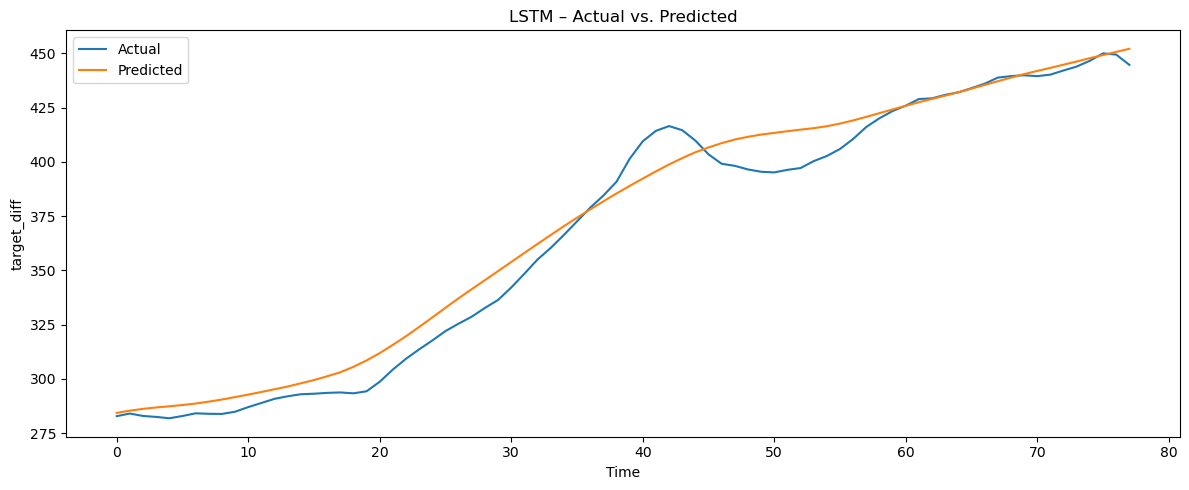

In [111]:
y_pred_scaled = model.predict(X_seq_test)
# Inverse scale
y_test_diff = y_scaler.inverse_transform(y_seq_test)
y_pred_diff = y_scaler.inverse_transform(y_pred_scaled)

# Reconstruct predictions
last_known = df['target'].iloc[-len(y_test_diff)-1]
y_pred_inv = np.r_[last_known, last_known + np.cumsum(y_pred_diff.flatten())][1:]
y_test_inv = df['target'].iloc[-len(y_test_diff):].values

rmse = math.sqrt(mean_squared_error(y_test_inv, y_pred_inv))
mae  = mean_absolute_error(y_test_inv, y_pred_inv)
r2   = r2_score(y_test_inv, y_pred_inv)

print(f"\n RMSE: {rmse:,.4f} | MAE: {mae:,.4f} | R²: {r2:,.4f}")

# -----------------------------
# 9) Plot
# -----------------------------
plt.figure(figsize=(12, 5))
plt.plot(y_test_inv, label="Actual")
plt.plot(y_pred_inv, label="Predicted")
plt.title("LSTM – Actual vs. Predicted")
plt.xlabel("Time")
plt.ylabel(TARGET_COL)
plt.legend()
plt.tight_layout()
plt.show()

Gradient-based feature importance (% of total sensitivity):

                   feature  grad_importance_pct
0    authorization_housing            17.516743
1             unemployment            16.986712
2     unsold_homeinventory            15.501736
3           housing_starts            11.853027
4        median_markettime             7.053093
5   household_debtpayments             6.060240
6              change_sale             5.064735
7            federal_funds             4.753116
8                sentiment             4.548181
9                 real_GDP             3.968281
10                  retail             1.822544
11        median_homeprice             1.653505
12                     cpi             1.611620
13             labor_force             0.809623
14              mortgage30             0.796853


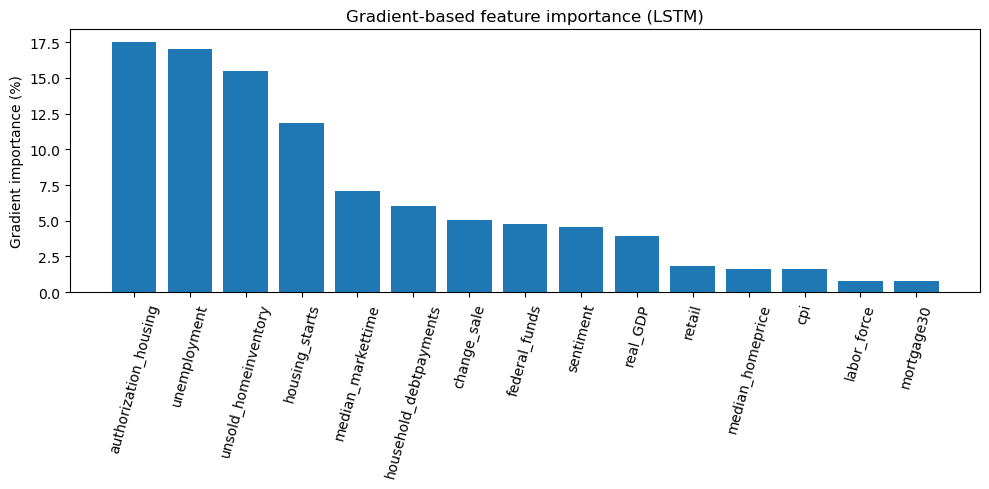

In [113]:
# ========= Gradient-based (global) feature importance =========
import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt

def gradient_importance_percent(model, X_seq, feature_names):
    """
    Returns a DataFrame with feature-wise importance (percent),
    computed as the mean absolute gradient of the model output
    w.r.t. the inputs, averaged over samples & timesteps.
    """
    X_tf = tf.convert_to_tensor(X_seq, dtype=tf.float32)

    with tf.GradientTape() as tape:
        tape.watch(X_tf)
        y_pred = model(X_tf, training=False)          # (n_samples, 1)

    grads = tape.gradient(y_pred, X_tf).numpy()       # (n_samples, lookback, n_features)
    fi = np.mean(np.abs(grads), axis=(0, 1))          # avg over samples & time
    fi = fi / fi.sum()                                # normalize to 1

    out = pd.DataFrame({
        "feature": feature_names,
        "grad_importance_pct": fi * 100.0
    }).sort_values("grad_importance_pct", ascending=False).reset_index(drop=True)
    return out

grad_imp = gradient_importance_percent(model, X_seq_test, feature_cols)

print("Gradient-based feature importance (% of total sensitivity):\n")
print(grad_imp)

plt.figure(figsize=(10,5))
plt.bar(grad_imp["feature"], grad_imp["grad_importance_pct"])
plt.xticks(rotation=75)
plt.ylabel("Gradient importance (%)")
plt.title("Gradient-based feature importance (LSTM)")
plt.tight_layout()
plt.show()

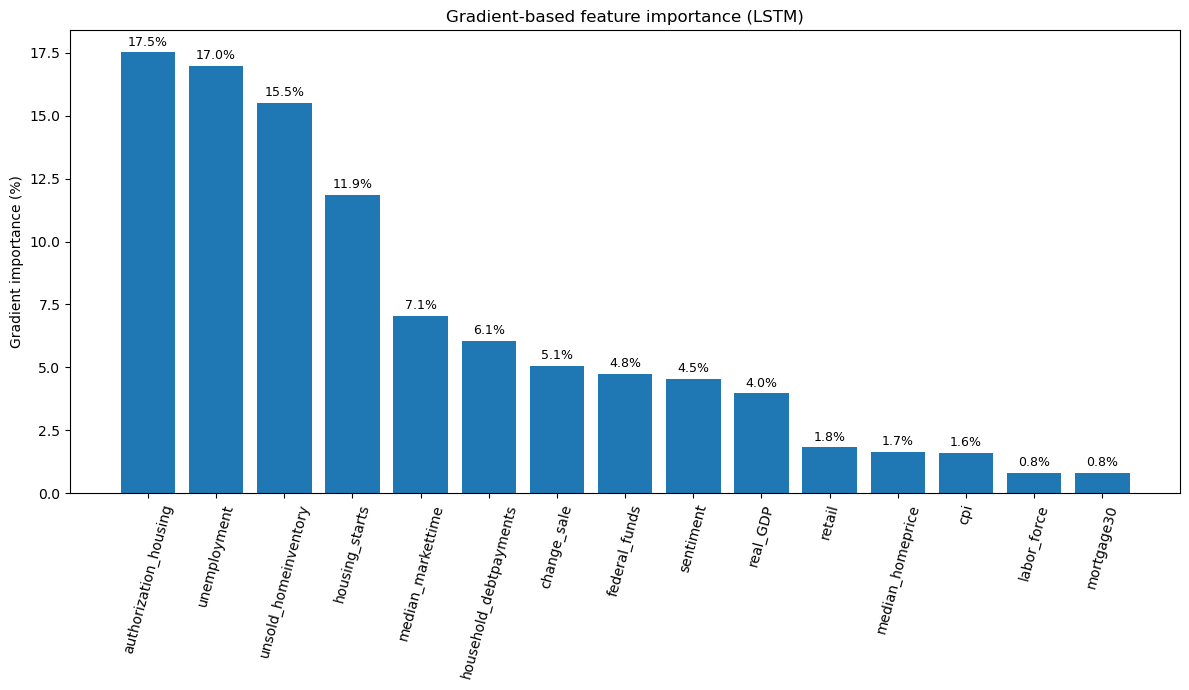

In [131]:
plt.figure(figsize=(12, 7))  # Wider and taller plot

bars = plt.bar(grad_imp["feature"], grad_imp["grad_importance_pct"])

# Add text labels above each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,  # center of bar
        height + 0.15,                       # a little above bar
        f"{height:.1f}%",                   # label text (1 decimal)
        ha="center", va="bottom", fontsize=9
    )

plt.xticks(rotation=75)
plt.ylabel("Gradient importance (%)")
plt.title("Gradient-based feature importance (LSTM)")
plt.tight_layout()
plt.show()
